In [1]:
import numpy as np

from helper_functions import *

os.listdir()

['train_series.csv',
 'train.csv',
 'test.csv',
 'test_series',
 'train_series',
 'sample_submission.csv',
 'test_series.csv']

In [2]:
print("Training size:", len(os.listdir("train_series")))
print("Testing size:", len(os.listdir("test_series")))

Training size: 1884
Testing size: 3


In [3]:
sample_submission_df = pd.read_csv("sample_submission.csv")
sample_submission_df

,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


In [4]:
train_df = pd.read_csv("train.csv")
train_df

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,1.2.826.0.1.3680043.8.498.99880021280666757817...,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Da...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4403,1.2.826.0.1.3680043.8.498.99881620336512626242...,[DATE]: *MR Knie Rechts 15ch AA Klinische Inli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4404,1.2.826.0.1.3680043.8.498.99926624968240681772...,"SAĞ DİZ MRG. Tetkik protokolü: Çok düzlemli, ç...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4405,1.2.826.0.1.3680043.8.498.99939100657291954890...,"MRI of Knee with \n-Locator, SG PD FatSat, SG ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
train_series_df = pd.read_csv("train_series.csv")
train_series_df

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal
...,...,...,...,...,...
24366,1.2.826.0.1.3680043.8.498.99957611207313098696...,1.2.826.0.1.3680043.8.498.54309001783901668483...,1,1,Axial
24367,1.2.826.0.1.3680043.8.498.99957611207313098696...,1.2.826.0.1.3680043.8.498.62870298129639401344...,1,1,Coronal
24368,1.2.826.0.1.3680043.8.498.99957611207313098696...,1.2.826.0.1.3680043.8.498.75079892939579407106...,0,0,Coronal
24369,1.2.826.0.1.3680043.8.498.99957611207313098696...,1.2.826.0.1.3680043.8.498.75317509519712148912...,1,1,Sagittal


In [6]:
test_df = pd.read_csv("test.csv")
test_df

,StudyInstanceUID
0,1.2.826.0.1.3680043.8.498.10047035057544427318...
1,1.2.826.0.1.3680043.8.498.10062861783145312629...
2,1.2.826.0.1.3680043.8.498.10067514707072572280...


In [7]:
test_series_df = pd.read_csv("test_series.csv")
test_series_df

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.11580656442259111255...,0,0,Axial
1,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.17811502614030631664...,0,0,Sagittal
2,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.30565395595045942404...,0,0,Sagittal
3,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.32856494541816845805...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.44334485654554877495...,1,1,Axial
5,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.10543708582570884867...,1,1,Sagittal
6,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.10818107180155454609...,1,1,Axial
7,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.34851887739080902195...,1,1,Sagittal
8,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.49057071886338907232...,0,0,Sagittal
9,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.49397095733611495516...,1,1,Coronal


In [8]:
os.listdir("test_series/1.2.826.0.1.3680043.8.498.10062861783145312629332250977456991776/1.2.826.0.1.3680043.8.498.34851887739080902195133258975769749352")

['1.2.826.0.1.3680043.8.498.37048966555909011198926128123642151716.dcm',
 '1.2.826.0.1.3680043.8.498.47285524535024930273505834699936536789.dcm',
 '1.2.826.0.1.3680043.8.498.25231632114478760327953699048382145691.dcm',
 '1.2.826.0.1.3680043.8.498.36835283583925472070711418355918617025.dcm',
 '1.2.826.0.1.3680043.8.498.38836884596369368455245039285251492520.dcm',
 '1.2.826.0.1.3680043.8.498.65317253796712137884377558291130598328.dcm',
 '1.2.826.0.1.3680043.8.498.11688744225297786289762769187264978368.dcm',
 '1.2.826.0.1.3680043.8.498.13084254668405463431997272140740829591.dcm',
 '1.2.826.0.1.3680043.8.498.69553280367099185891878837811009474685.dcm',
 '1.2.826.0.1.3680043.8.498.90004897070573342603159750576897268882.dcm',
 '1.2.826.0.1.3680043.8.498.12733786874672165711046267196113100263.dcm',
 '1.2.826.0.1.3680043.8.498.73803764811418752235353777530706204166.dcm',
 '1.2.826.0.1.3680043.8.498.92095038313101045783948275330871781005.dcm',
 '1.2.826.0.1.3680043.8.498.35670674927762455101565

In [9]:
study_ids = os.listdir("train_series")
match_rate = train_series_df["StudyInstanceUID"].isin(study_ids).mean()

print(f"Percentage of series with images: {match_rate:.2%}")

Percentage of series with images: 42.70%


In [10]:
labeled_data = train_df.dropna()

match_rate = labeled_data["StudyInstanceUID"].isin(study_ids).mean()
number_labeled_instances = labeled_data["StudyInstanceUID"].isin(study_ids).sum()
print(f"Percentage of labeled series with images: {match_rate:.2%}")
print(f"# of labeled series with images: {number_labeled_instances}")
len(labeled_data)

Percentage of labeled series with images: 48.28%
# of labeled series with images: 28


58

In [11]:
# Filtering out for images downloaded, already confirmed test data sets are fine
train_df = train_df[train_df["StudyInstanceUID"].isin(study_ids)]
train_series_df = train_series_df[train_series_df["StudyInstanceUID"].isin(study_ids)]
labeled_data = labeled_data[labeled_data["StudyInstanceUID"].isin(study_ids)]

labeled_series_df = train_series_df[train_series_df["StudyInstanceUID"].isin(labeled_data["StudyInstanceUID"])]
labeled_series_df

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
163,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,0,Sagittal
164,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.12451507871565834868...,0,0,Coronal
165,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
166,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
167,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial
...,...,...,...,...,...
10006,1.2.826.0.1.3680043.8.498.30246079718471552972...,1.2.826.0.1.3680043.8.498.10125030789765676430...,1,1,Coronal
10007,1.2.826.0.1.3680043.8.498.30246079718471552972...,1.2.826.0.1.3680043.8.498.12908352013592575797...,1,1,Axial
10008,1.2.826.0.1.3680043.8.498.30246079718471552972...,1.2.826.0.1.3680043.8.498.13364655615747190896...,0,0,Sagittal
10009,1.2.826.0.1.3680043.8.498.30246079718471552972...,1.2.826.0.1.3680043.8.498.73098240504448530683...,1,1,Sagittal


Plane: Sagittal
Fluid Sensitive: 0
Fat Suppression: 0
ACL: 0.0    MCL: 1.0    Medial Meniscus: 0.0    Lateral Meniscus: 0.0    Medial OA: 0.0    
Lateral OA: 0.0   PF OA: 0.0   Effusion: 0.0   Synovitis: 0.0   Baker's: 0.0   Contusion: 1.0   Fracture: 0.0   

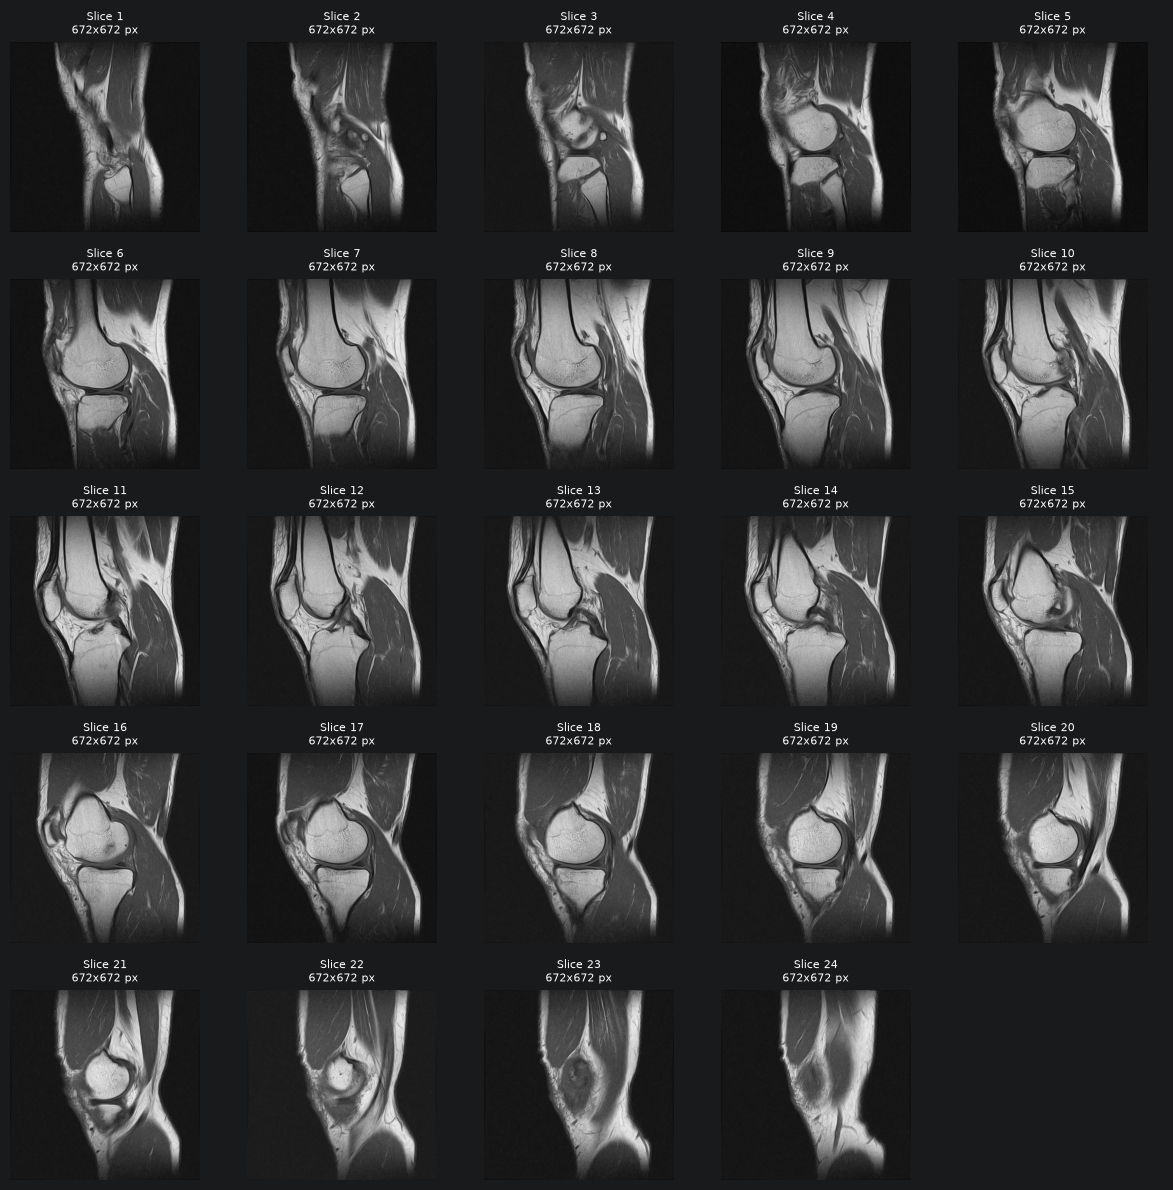

In [12]:
# Displaying random images of labeled data
random_row = labeled_series_df.sample(n=1).iloc[0]
plane = random_row["Anatomical_Plane"]
fluid_sensitive = random_row["Fluid_Sensitive"]
fat_suppression = random_row["Fat_Suppression"]
images_path = "train_series/" + random_row["StudyInstanceUID"] + "/" + random_row["SeriesInstanceUID"]
label_values = labeled_data[labeled_data["StudyInstanceUID"] == random_row["StudyInstanceUID"]].drop(columns=["StudyInstanceUID", "Report"])

print("Plane:", plane)
print("Fluid Sensitive:", fluid_sensitive)
print("Fat Suppression:", fat_suppression)

for col in label_values.columns[:5]:
    print(f"{col}: {label_values.iloc[0][col]}", end="    ")
print()
for col in label_values.columns[5:]:
    print(f"{col}: {label_values.iloc[0][col]}", end="   ")

dicom_example = display_dcm_series_matrix(images_path)

In [13]:
print(dicom_example.pixel_array.shape)
dicom_example.pixel_array

(672, 672)


array([[  5,  -4,  -9, ...,   5,  -2,   0],
       [  5,  -1,  -5, ...,   8,   2,   2],
       [ -1, -21, -44, ..., -13, -51, -22],
       ...,
       [-22,  -1,   2, ..., -44,  13,  24],
       [  0,   4,   5, ...,  -6,   5,  13],
       [  2,   3,   4, ...,   1,   8,  10]], shape=(672, 672), dtype=int16)

In [14]:
print("Largest Possible Value:", (2 ** dicom_example.BitsStored) - 1)
print("Largest Spotted Value:", np.max(dicom_example.pixel_array))

Largest Possible Value: 65535
Largest Spotted Value: 9718


In [15]:
random_row = labeled_series_df.sample(n=1).iloc[0]
instance_id = random_row["StudyInstanceUID"]
train_series_df[train_series_df["StudyInstanceUID"] == instance_id]

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
6493,1.2.826.0.1.3680043.8.498.13335129881737731410...,1.2.826.0.1.3680043.8.498.13285315477543193167...,1,1,Axial
6494,1.2.826.0.1.3680043.8.498.13335129881737731410...,1.2.826.0.1.3680043.8.498.32243142107334417600...,0,0,Sagittal
6495,1.2.826.0.1.3680043.8.498.13335129881737731410...,1.2.826.0.1.3680043.8.498.44481757782902229277...,1,1,Sagittal
6496,1.2.826.0.1.3680043.8.498.13335129881737731410...,1.2.826.0.1.3680043.8.498.68216362009231374856...,0,0,Coronal
6497,1.2.826.0.1.3680043.8.498.13335129881737731410...,1.2.826.0.1.3680043.8.498.96243991448267206821...,1,1,Coronal


In [21]:
slices = []
pixels = []
dcm_file = None
for study_id in study_ids:
    for series_id in os.listdir("train_series/" + study_id):
        images_path = os.listdir("train_series/" + study_id + "/" + series_id)
        try:
            dcm_file = pydicom.dcmread("train_series/" + study_id + "/" + series_id + "/" + images_path[0])
            pixels.append(dcm_file.pixel_array.shape[0])
            slices.append(len(images_path))
        except Exception:
            continue

Min slices: 11
Max slices: 320
Average Slices: 33.769782082324454

Min pixels: 192
Max pixels: 1280
Average pixels: 537.0003874092009



In [24]:
print("Min slices:", min(slices))
print("Max slices:", max(slices))
print("Average Slices:", np.mean(slices))
print("Median Slices:", np.median(slices), end="\n\n")

print("Min pixels:", min(pixels))
print("Max pixels:", max(pixels))
print("Average pixels:", np.mean(pixels))
print("Median pixels:", np.median(pixels))

Min slices: 11
Max slices: 320
Average Slices: 33.769782082324454
Median Slices: 30.0

Min pixels: 192
Max pixels: 1280
Average pixels: 537.0003874092009
Median pixels: 512.0


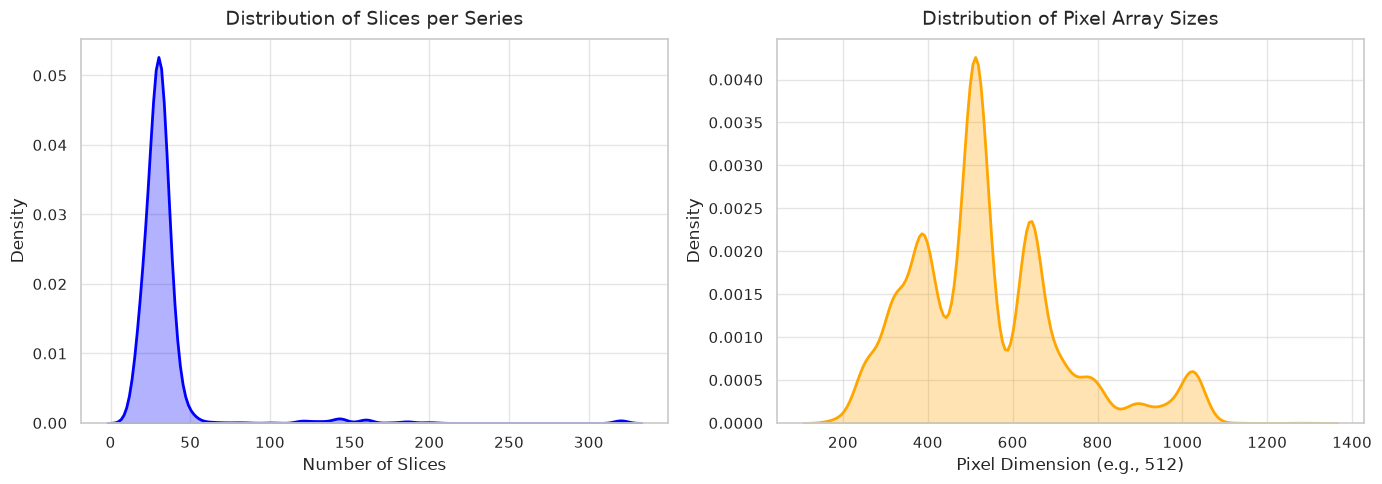

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visualization style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of Slices
sns.kdeplot(data=slices, ax=axes[0], color="blue", fill=True, alpha=0.3, linewidth=2)
axes[0].set_title("Distribution of Slices per Series", fontsize=14, pad=10)
axes[0].set_xlabel("Number of Slices", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)

# Plot 2: Distribution of Pixels (Image Dimension)
sns.kdeplot(data=pixels, ax=axes[1], color="orange", fill=True, alpha=0.3, linewidth=2)
axes[1].set_title("Distribution of Pixel Array Sizes", fontsize=14, pad=10)
axes[1].set_xlabel("Pixel Dimension (e.g., 512)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [30]:
# Looking for how many slices I need to have at least 95% of the data set if i filtered out instances with too low slices

slices = sorted(slices)
print(slices[-int(0.95 * len(slices))])

18
